# 1. Выбор датасета.

The total number of records in the dataset is 1436 cars. Description of each of variables is as below:

Columns:
- Id: Unique identifier for each car entry.
- Model: The model name of the Toyota Corolla.
- Price: The selling price of the used car.
- Age_08_04: The age of the car in months as of August 2004.
- Mfg_Month: The manufacturing month of the car.
- Mfg_Year: The manufacturing year of the car.
- KM: The number of kilometers the car has been driven.
- Fuel_type: The type of fuel the car uses (e.g., Petrol, Diesel).
- HP: Horsepower, a measure of the engine's power.
- Met_Color: Binary indicator for metallic paint (0 = No, 1 = Yes).
- Color: The exterior color of the car.
- Automatic: Binary indicator for automatic transmission (0 = No, 1 = Yes).
- CC: Engine size in cubic centimeters.
- Doors: Number of doors on the car.
- Cylinders: Number of cylinders in the engine.
- Gears: Number of gears in the transmission.
- Quarterly: Quarterly tax for the car.
- Weight: Weight of the car.
- Mfr_Guarantee: Binary indicator for manufacturer's guarantee (0 = No, 1 = Yes).
- BOVAG_Guarantee: Binary indicator for BOVAG guarantee (0 = No, 1 = Yes).
- Guarantee_Period: Duration of the guarantee in months.
- ABS: Binary indicator for Anti-lock Braking System (0 = No, 1 = Yes).
- Airbag_1: Binary indicator for the presence of Airbag 1 (0 = No, 1 = Yes).
- Airbag_2: Binary indicator for the presence of Airbag 2 (0 = No, 1 = Yes).
- Airco: Binary indicator for air conditioning (0 = No, 1 = Yes).
- Automatic_airco: Binary indicator for automatic air conditioning (0 = No, 1 = Yes).
- Boardcomputer: Binary indicator for a board computer (0 = No, 1 = Yes).
- CD_Player: Binary indicator for the presence of a CD player (0 = No, 1 = Yes).
- Central_Lock: Binary indicator for central locking system (0 = No, 1 = Yes).
- Powered_Windows: Binary indicator for powered windows (0 = No, 1 = Yes).
- Power_Steering: Binary indicator for power steering (0 = No, 1 = Yes).
- Radio: Binary indicator for a radio (0 = No, 1 = Yes).
- Mistlamps: Binary indicator for mist lamps (0 = No, 1 = Yes).
- Sport_Model: Binary indicator for a sport model (0 = No, 1 = Yes).
- Backseat_Divider: Binary indicator for a backseat divider (0 = No, 1 = Yes).
- Metallic_Rim: Binary indicator for metallic rims (0 = No, 1 = Yes).
- Radio_cassette: Binary indicator for a radio cassette player (0 = No, 1 = Yes).
- Parking_Assistant: Binary indicator for a parking assistant (0 = No, 1 = Yes).
- Tow_Bar: Binary indicator for the presence of a tow bar (0 = No, 1 = Yes).

# 2. Первичный анализ данных (EDA) и предобработка.

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas
import numpy as np
from sklearn.preprocessing import TargetEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from scipy.stats import kstest, norm
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [150]:
df = pandas.read_csv('ToyotaCorolla.csv')
df

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,69,12,1998,20544,Petrol,86,1,...,1,1,0,1,1,1,0,0,0,0
1432,1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,10845,72,9,1998,19000,Petrol,86,0,...,0,1,0,0,1,1,0,0,0,0
1433,1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,8500,71,10,1998,17016,Petrol,86,0,...,0,1,0,0,0,1,0,0,0,0
1434,1441,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,7250,70,11,1998,16916,Petrol,86,1,...,0,0,0,0,0,1,0,0,0,0


In [151]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

In [152]:
print("Кол-во записей:\n", df.count())
print("\nСтатистика:\n", df.describe(include="all"))
print("\nКол-во пропусков данных:\n", df.isnull().sum())

Кол-во записей:
 Id                   1436
Model                1436
Price                1436
Age_08_04            1436
Mfg_Month            1436
Mfg_Year             1436
KM                   1436
Fuel_Type            1436
HP                   1436
Met_Color            1436
Color                1436
Automatic            1436
CC                   1436
Doors                1436
Cylinders            1436
Gears                1436
Quarterly_Tax        1436
Weight               1436
Mfr_Guarantee        1436
BOVAG_Guarantee      1436
Guarantee_Period     1436
ABS                  1436
Airbag_1             1436
Airbag_2             1436
Airco                1436
Automatic_airco      1436
Boardcomputer        1436
CD_Player            1436
Central_Lock         1436
Powered_Windows      1436
Power_Steering       1436
Radio                1436
Mistlamps            1436
Sport_Model          1436
Backseat_Divider     1436
Metallic_Rim         1436
Radio_cassette       1436
Parking_Assistant    

In [153]:
print('Model: ', df['Model'].unique().size)
print('Fuel_Type: ', df['Fuel_Type'].unique().size)
print('Color: ', df['Color'].unique().size)

Model:  319
Fuel_Type:  3
Color:  10


In [154]:
df['Mfg_Year'].unique()

array([2002, 2003, 2004, 2001, 2000, 1999, 1998])

# 3. Работа с признаками (Feature Engineering).

Установим столбец Id как id датасета.

In [155]:
df.set_index("Id", inplace=True)
df.head()

,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
Id,,,,,,,,,,,,,,,,,,,,,
1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,...,1,1,0,0,0,1,0,0,0,0
2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,Silver,...,0,1,0,0,0,1,0,0,0,0
3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,Blue,...,0,1,0,0,0,1,0,0,0,0
4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,Black,...,0,1,0,0,0,1,0,0,0,0
5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,Black,...,1,1,0,1,0,1,0,0,0,0


У нас очень мало уникальных значений Mfg_Year. Можно просто отнять от всех значений минимальное значение (1998), чтобы не энкодить. Но есть предположение, что этот признак сильно скоррелирован с Age_08_04, как и Mfg_Month. Поэтому стоит проверить на тепловой карте эти предположения и при необходимости просто удалить эти столбцы.

Также по матрице корреляций стоит проверить предположение о корреляции столбцов 'Color' и 'Met_Color', так как непонятно, что именно значит металлический цвет и почему он не занесен в столбец 'Color', если это такой же цвет, как и все остальные.

Для столбца Model лучше всего будет применить Target Encoding, так как в этом столбце много уникальных значений (высокая кардильность) и класс машины (а определенная модель принадлежит к определенному классу) непосредственно влияет на цену. Но если применить Target Encoding на неразделенном датасете, то модель может переобучиться. Поэтому оставим это тоже на потом. Модель не будет бояться новых моделей авто, так как все энкодеры из category_encoders новой модели присваивают глобальное среднее по всему датасету. Так как моделей очень много, мы не можем поставить стратификацию и быть уверенными в адекватности и хотя бы примерном соответствии цен из тренировочного и тестового датасета. Поэтому примерним сглаживание, которое будет в степени, зависящей от частоты встречаемости модели в датасете, подмешивать среднее по цене модели к глобальному среднему цены автомобилей.

Для столбца Fuel_Type можно применить One Hot Encoding, так как всего 3 уникальных значения, что несильно увеличит размерность пространства.

Перед тем как энкодить столбец Color, стоит проверить, стоит ли его вообще оставлять. Для этого вычислим корреляционное отношение для этого столбца.

In [156]:
mean_global = df['Price'].mean()
group_stats = df.groupby('Color')['Price'].agg(['count', 'mean'])
bss = (group_stats['count'] * (group_stats['mean'] - mean_global)**2).sum()
tss = ((df['Price'] - mean_global)**2).sum()
np.sqrt(bss / tss)

np.float64(0.23362468083663335)

Корреляционное отношение равно 0.2336, это не сильно маленькое значение, так что можно оставить столбец Color. Столбец Color хоть и имеет 10 категорий, что сильно увеличивает размерность пространства, но лучше всего к нему применить One Hot Encoding, так как никакой зависимости между категориями нет, а значит не применить Label Encoding. Target Encoding и Feature Hashing не применить, так как Target Encoding даст рандомные значения, так какцвет скорее всего слабо скоррелирован с ценой, а Feature Hashing будет бесполезен по этой же причине.

In [157]:
df1 = df.copy().drop(['Color'], axis=1)
df = pandas.get_dummies(df, columns=['Color'], drop_first=True, dtype=int)

Аналогично для столбца Fuel_Type.

In [158]:
mean_global = df['Price'].mean()
group_stats = df.groupby('Fuel_Type')['Price'].agg(['count', 'mean'])
bss = (group_stats['count'] * (group_stats['mean'] - mean_global)**2).sum()
tss = ((df['Price'] - mean_global)**2).sum()
np.sqrt(bss / tss)

np.float64(0.06581546560274948)

Столбец Fuel_Type слабо скоррелирован с целевой переменной, значит его можно удалить.

In [159]:
df = df.drop(['Fuel_Type'], axis=1)
df1 = df1.drop(['Fuel_Type'], axis=1)

Построим матрицу корреляций.

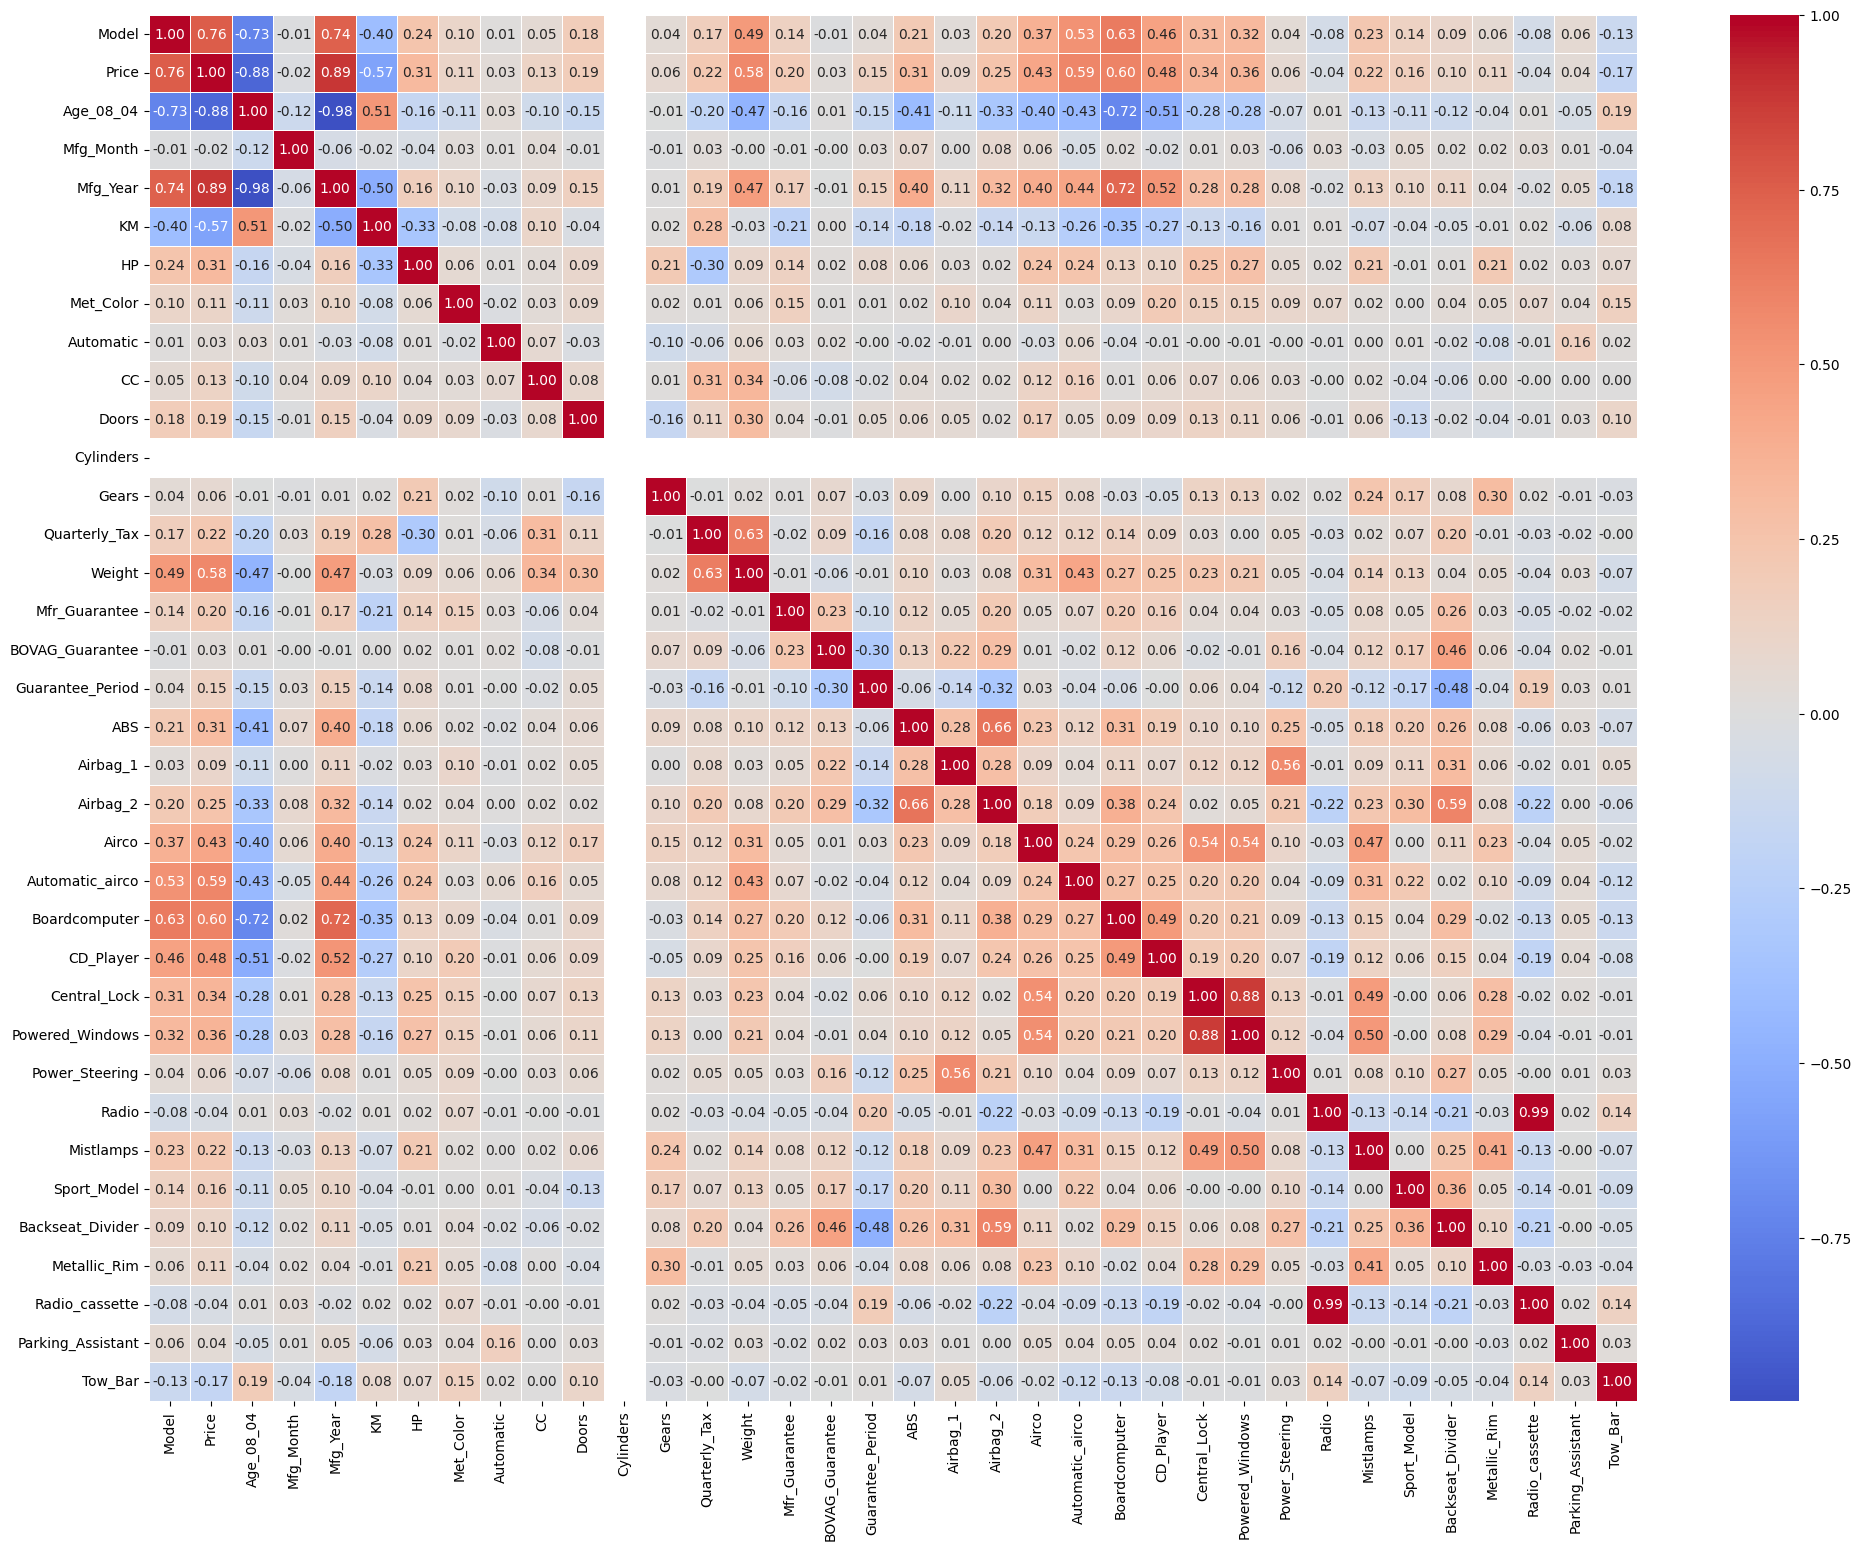

In [160]:
encoder = TargetEncoder(target_type="continuous")
df1['Model'] = encoder.fit_transform(df1[['Model']], df1['Price'])

corr_matrix = df1.corr()

plt.figure(figsize=(24, 18))

sns.heatmap(corr_matrix, 
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.show()

In [161]:
df1['Cylinders'].unique()

array([4])

Удаляем колонку 'Cylinders', так как в ней только 1 значение. Удаляем колонки 'Mfg_Month' и 'Mfg_Year'. Удаляем столбцы, которые мало влияют на целевую переменную, а именно: 'Automatic', 'Gears', 'BOVAG_Guarantee', 'Power_Steering', 'Radio', 'Radio_cassette', 'Parking_Assistant'. Признаки 'Central_Lock' и 'Powered_Windows' имеют довольно высокую корреляцию, поэтому удаляем тот, который меньше коррелирует с целевой переменной, а именно 'Central_Lock'.

In [162]:
df = df.drop(['Cylinders', 'Mfg_Month', 'Mfg_Year', 'Automatic', 'Gears', 'BOVAG_Guarantee', 'Power_Steering', 'Radio', 'Radio_cassette', 'Parking_Assistant', 'Central_Lock'], axis=1)
df1 = df1.drop(['Cylinders', 'Mfg_Month', 'Mfg_Year', 'Automatic', 'Gears', 'BOVAG_Guarantee', 'Power_Steering', 'Radio', 'Radio_cassette', 'Parking_Assistant', 'Central_Lock'], axis=1)

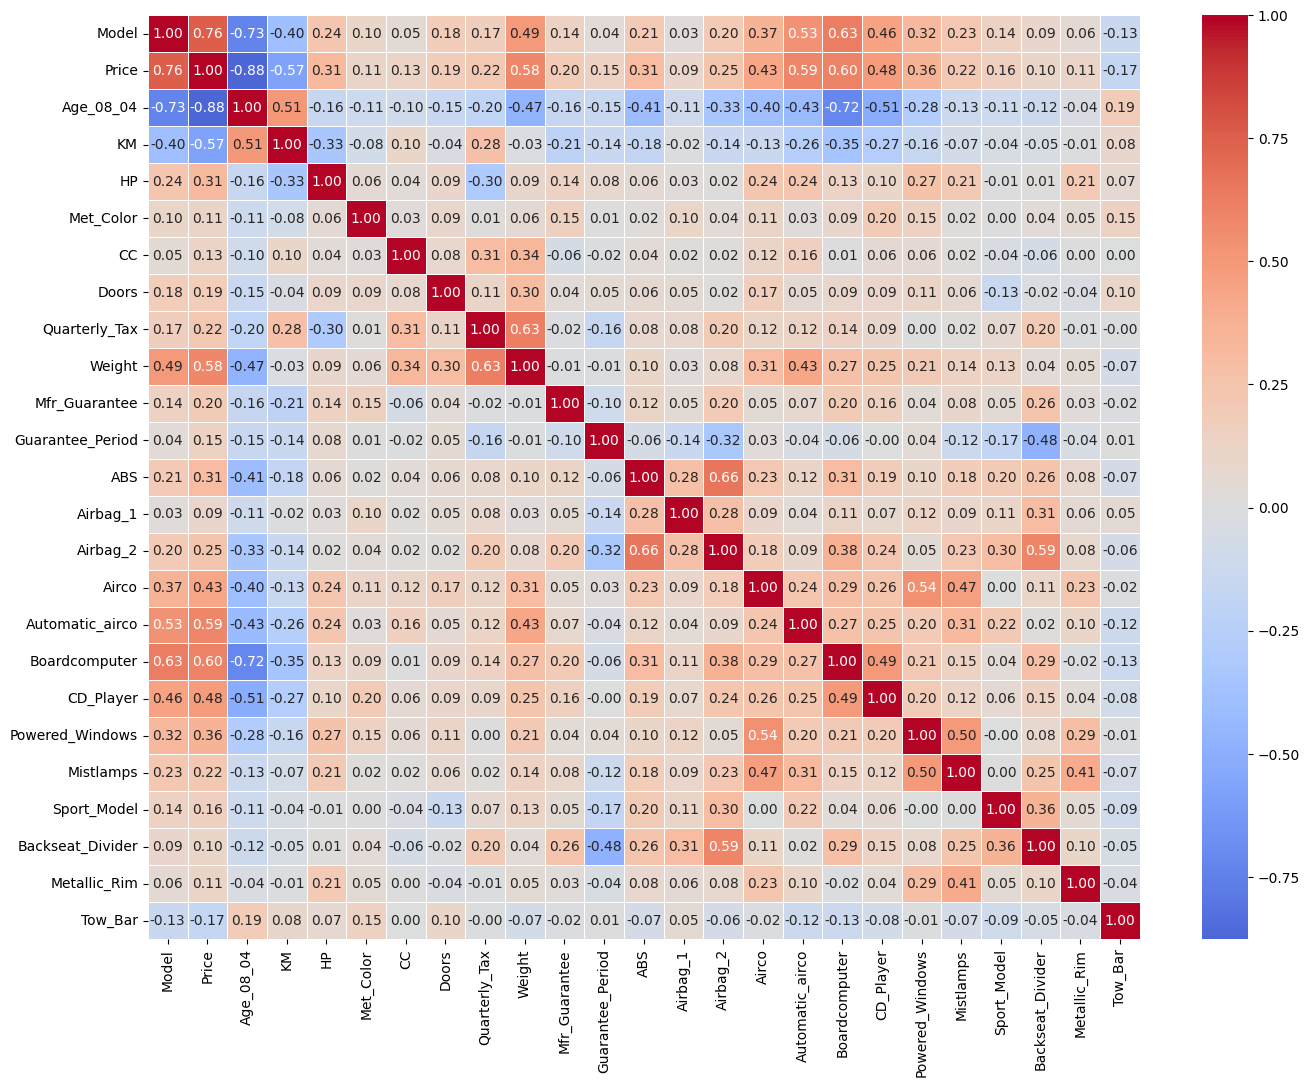

In [163]:
corr_matrix = df1.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(corr_matrix, 
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.show()

Проверим наш датасет на аномальные выбросы.

In [164]:
num_df = df.select_dtypes(include=['number'])
statistics = pandas.DataFrame(columns=num_df.columns)
statistics.loc['skewness'] = num_df.skew()     # Асимметрия
statistics.loc['kurtosis'] = num_df.kurt()     # Эксцесс
statistics.T

,skewness,kurtosis
Price,1.703885,3.737781
Age_08_04,-0.826702,-0.076632
KM,1.015912,1.685057
HP,0.955836,8.836434
Met_Color,-0.747029,-1.443961
CC,27.431793,930.711227
Doors,-0.076395,-1.874765
Quarterly_Tax,1.993834,4.298345
Weight,3.108639,19.362901
Mfr_Guarantee,0.368588,-1.866745


Построим BoxPlot'ы признаков, у которых большая ассиметрия или эксцесс.

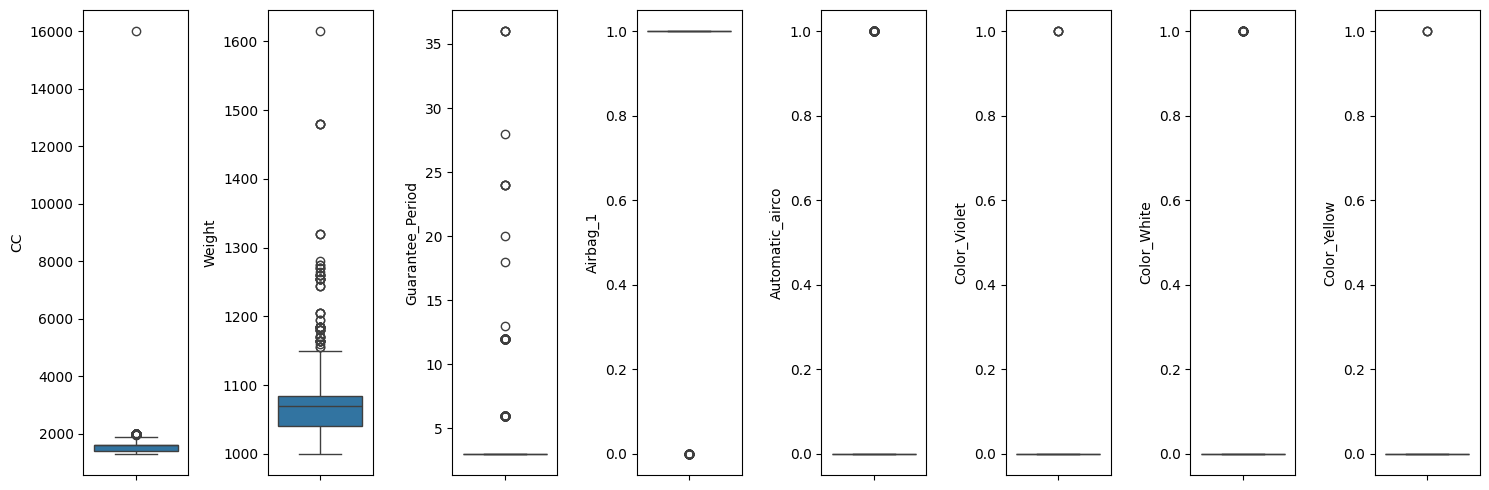

In [165]:
fig, axes = plt.subplots(1, 8, figsize=(15, 5))
axes = axes.flatten()

sns.boxplot(data=df, y='CC', ax=axes[0])
sns.boxplot(data=df, y='Weight', ax=axes[1])
sns.boxplot(data=df, y='Guarantee_Period', ax=axes[2])
sns.boxplot(data=df, y='Airbag_1', ax=axes[3])
sns.boxplot(data=df, y='Automatic_airco', ax=axes[4])
sns.boxplot(data=df, y='Color_Violet', ax=axes[5])
sns.boxplot(data=df, y='Color_White', ax=axes[6])
sns.boxplot(data=df, y='Color_Yellow', ax=axes[7])

plt.tight_layout()

In [166]:
df[df['CC'] > 15000]

,Model,Price,Age_08_04,KM,HP,Met_Color,CC,Doors,Quarterly_Tax,Weight,...,Tow_Bar,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow
Id,,,,,,,,,,,,,,,,,,,,,
81,TOYOTA Corolla 1.6 5drs 1 4/5-Doors,18950,25,20019,110,1,16000,5,100,1180,...,0,0,1,0,0,0,0,0,0,0


Явно в таком автомобиле не будет двигателя такого объема. Об этом нам также говорит и 1.6 в названии авто. Так что это опечатка, исправим.

In [167]:
df.loc[df['CC'] > 15000, 'CC'] = 1600

Я сделал базовую предобработку данных. Она отличалась от предобработки для линейной регрессии, так как для деревьев не требуется скейлить признаки.

# 4. Разделение выборки.

Разделим выборку на параметры и целевую переменную.

In [168]:
X = df.copy().drop(["Price"], axis=1)
y = df["Price"].copy()

Далее разделим данные на train и test.

In [169]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

Разделил выборку на train и test в соотношении 80/20.

При кросс-валидации можно делить на какое угодно количество частей, но часто используют 5 частей. 

Кросс-валидацию можно не использовать. Вместо этого можно отделить от выборки часть validation и использовать ее для настройки гиперпараметров. А результат все так же проверять на test.

# 5. Обучение моделей.

TargetEncoding для параметра Model.

In [170]:
encoder = TargetEncoder(target_type="continuous", smooth=5)
X_train['Model'] = encoder.fit_transform(X_train[['Model']], y_train)
X_test['Model'] = encoder.transform(X_test[['Model']])

Обучим дерево решений.

In [171]:
dtr = DecisionTreeRegressor(max_depth=10, random_state=42)
dtr.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

Обучим случайный лес.

In [172]:
rfr = RandomForestRegressor(n_estimators=200, max_depth=10, bootstrap=True, random_state=42, max_features=0.33)
rfr.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.33
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

Обучилась быстрее модель дерева решений. Одинаковой скорости добиться можно, если деревья обучать параллельно.

# 6. Оценка качества и сравнение моделей.

In [173]:
y_pred_dtr = dtr.predict(X_test)
y_pred_rfr = rfr.predict(X_test)

dtr_mse = mean_squared_error(y_test, y_pred_dtr)
rfr_mse = mean_squared_error(y_test, y_pred_rfr)

dtr_rmse = np.sqrt(dtr_mse)
rfr_rmse = np.sqrt(rfr_mse)

dtr_mae = mean_absolute_error(y_test, y_pred_dtr)
rfr_mae = mean_absolute_error(y_test, y_pred_rfr)

dtr_mape = mean_absolute_percentage_error(y_test, y_pred_dtr)
rfr_mape = mean_absolute_percentage_error(y_test, y_pred_rfr)

dtr_r2 = r2_score(y_test, y_pred_dtr)
rfr_r2 = r2_score(y_test, y_pred_rfr)

results = pandas.DataFrame([['Decision tree regressor', dtr_mse, dtr_rmse, dtr_mae, dtr_mape, dtr_r2],
                            ['Random forest regressor', rfr_mse, rfr_rmse, rfr_mae, rfr_mape, rfr_r2]], 
                            columns=['Model', 'MSE', 'RMSE', 'MAE', 'MAPE', 'R2'])

results

,Model,MSE,RMSE,MAE,MAPE,R2
0,Decision tree regressor,1.521340e+06,1233.426084,933.650215,0.097889,0.885980
1,Random forest regressor,9.704140e+05,985.095939,747.816152,0.077448,0.927271


Одно дерево работает значительно хуже, чем случайный лес, что видно в таблице сверху.

у линейной регрессии были следующие результаты:

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Model</th>
      <th>MSE</th>
      <th>RMSE</th>
      <th>MAE</th>
      <th>MAPE</th>
      <th>R2</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>Basic linear regression</td>
      <td>1.215327e+06</td>
      <td>1102.418544</td>
      <td>776.276593</td>
      <td>0.077119</td>
      <td>0.908915</td>
    </tr>
    <tr>
      <th>1</th>
      <td>Ridge linear regression</td>
      <td>1.199497e+06</td>
      <td>1095.215328</td>
      <td>772.299746</td>
      <td>0.076754</td>
      <td>0.910102</td>
    </tr>
    <tr>
      <th>2</th>
      <td>Lasso linear regression</td>
      <td>1.123823e+06</td>
      <td>1060.105170</td>
      <td>760.980248</td>
      <td>0.076154</td>
      <td>0.915773</td>
    </tr>
    <tr>
      <th>3</th>
      <td>ElasticNet linear regression</td>
      <td>1.147789e+06</td>
      <td>1071.348936</td>
      <td>764.002526</td>
      <td>0.076278</td>
      <td>0.913977</td>
    </tr>
  </tbody>
</table>
</div>

На все вопросы из пункта 3 ответы даны в дз по линейной регрессии. Здесь считаю нужным только сравнить лин рег и случайный лес. Как видно, результаты примерно одинаковые, но случайный лес справился немного лучше.